# CMPE 260 Project 1: Teaching DQN to Play Pong

**Team:** Jaya Vyas · Prachi Gupta · Keerthana Muralidharan · Yashaswini Dinesh
**Hardware:** Google Colab, NVIDIA Tesla T4
**Code:** textbook repo (Lapan, *Deep Reinforcement Learning Hands-On*, Chapter 6), ported to Gymnasium 1.x

This notebook brings every experiment together in one place.

| Section | What it covers |
|---|---|
| 1 | Setup |
| 2 | The algorithm we started from and what we changed |
| 3 | Step 1: baseline DQN with ε-greedy |
| 4 | Step 2: Boltzmann and Max-Boltzmann exploration |
| 5 | Step 3: Prioritized Experience Replay (10k and 50k buffers) |
| 6 | Monitoring with TensorBoard |
| 7 | Comparison tables: baseline vs every technique |
| 8 | Why the techniques work |
| 9 | Our contributions |
| 10 | Test games |
| 11 | Save everything to a zip |

**Training is switched off** (`RUN_TRAINING = False`), because each run takes 1.5 to 4.5 hours on a T4.
Training cells print the exact command we used; results load from the saved TensorBoard logs, console logs and tables in this folder.

## 1. Setup

In [ ]:
# ---- Settings -------------------------------------------------------------
RUN_TRAINING = False                                     # True = retrain from scratch (1.5-4.5 h per run)
DRIVE_FOLDER = "/content/drive/MyDrive/CMPE260_Project1" # where this project folder lives on Drive

import os, sys, glob, re, shutil
IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    PROJ = DRIVE_FOLDER
else:
    PROJ = os.path.abspath("..")      # running locally from the notebooks/ folder
os.chdir(PROJ)
print("Project folder:", PROJ)
print(sorted(p for p in os.listdir(PROJ) if not p.startswith(".")))

In [ ]:
if IN_COLAB:
    !pip install -q "gymnasium[atari]>=1.0" "ale-py>=0.9" opencv-python-headless tensorboardX tabulate
    !nvidia-smi --query-gpu=name,memory.total --format=csv,noheader

**Bring in the 10k-buffer logs.** The 10k runs were trained from our original Drive folder.
If it still exists, this copies their TensorBoard logs and models here, so TensorBoard and the checks below can see all runs together.

In [ ]:
OLD = "/content/drive/MyDrive/Reinforcement Learning Proj1/Chapter06"   # original 10k-run folder
os.makedirs("runs/buffer_10k", exist_ok=True)
os.makedirs("models", exist_ok=True)
if os.path.isdir(OLD):
    for d in glob.glob(f"{OLD}/runs/*/"):
        dst = os.path.join("runs/buffer_10k", os.path.basename(d.rstrip("/")))
        if not os.path.exists(dst):
            shutil.copytree(d, dst)
    for f in glob.glob(f"{OLD}/*.dat"):
        shutil.copy2(f, "models/")
    print("Copied 10k runs and models from", OLD)
else:
    print("Original 10k folder not found here; the 10k results load from results/buffer_10k/ instead.")
print("TensorBoard run folders -> 10k:", len(glob.glob("runs/buffer_10k/*/")),
      "| 50k:", len(glob.glob("runs/buffer_50k/*/")))

**Helpers** used by the training cells.

In [4]:
def train(args, log_name):
    """Run one training job, or show the command we used when training is switched off."""
    cmd = f"python {args}"
    if not RUN_TRAINING:
        print("Training skipped (RUN_TRAINING = False). Command used for this run:")
        print("   ", cmd)
        return
    os.makedirs("logs", exist_ok=True)
    get_ipython().system(f"{cmd} 2>&1 | tee logs/{log_name}")

def set_buffer(replay_size, beta_frames=100_000):
    """Set the replay buffer size in 05/06 and PER's beta annealing length in 06."""
    for f in ["05_dqn_pong_maxboltzmann.py", "06_dqn_pong_per.py"]:
        src = open(f).read()
        src = re.sub(r"^REPLAY_SIZE = .*$", f"REPLAY_SIZE = {replay_size}", src, flags=re.M)
        if f.startswith("06"):
            src = re.sub(r"^BETA_FRAMES = .*$", f"BETA_FRAMES = {beta_frames}", src, flags=re.M)
        open(f, "w").write(src)
    !grep -n "^REPLAY_SIZE\|^BETA_FRAMES" 05_dqn_pong_maxboltzmann.py 06_dqn_pong_per.py

## 2. What we started from and what we changed

**The algorithm: Deep Q-Network (DQN)**, from the textbook's Chapter 6 (Mnih et al., 2015). Each step the agent:

1. **Plays:** sees the last 4 frames (84×84 grayscale) and picks a move with ε-greedy.
2. **Remembers:** stores (state, action, reward, next state) in a replay buffer.
3. **Learns:** samples 32 stored steps and moves Q(s,a) toward r + γ·max Q̂(s′,a′).
4. **Stays steady:** copies its weights into a frozen target network Q̂ every 1,000 frames.

The hyperparameters, read straight from the baseline script:

In [5]:
!grep -nE "^(GAMMA|BATCH_SIZE|REPLAY_SIZE|LEARNING_RATE|SYNC_TARGET_FRAMES|REPLAY_START_SIZE|EPSILON_DECAY_LAST_FRAME|EPSILON_START|EPSILON_FINAL)" 02_dqn_pong.py

20:GAMMA = 0.99
21:BATCH_SIZE = 32
22:REPLAY_SIZE = 10000
23:LEARNING_RATE = 1e-4
24:SYNC_TARGET_FRAMES = 1000
25:REPLAY_START_SIZE = 10000
27:EPSILON_DECAY_LAST_FRAME = 10**5
28:EPSILON_START = 1.0
29:EPSILON_FINAL = 0.02


**What we changed in the textbook code.** The 2018 code does not run on current libraries, so we made only the fixes they require
(Gymnasium's new `reset()`/`step()` API, NumPy 2, PyTorch boolean masks). The network file is untouched.
Each experiment lives in its own new script, so the baseline stays exactly as published. Every changed line is in `CHANGES_vs_repo.diff`:

In [6]:
import pandas as pd
from IPython.display import display, Markdown, Image

counts, cur = {}, None
for line in open("CHANGES_vs_repo.diff"):
    if line.startswith("+++ "):
        cur = line[4:].strip().replace("ported/", "")
        counts[cur] = [0, 0]
    elif cur and line.startswith("+") and not line.startswith("+++"):
        counts[cur][0] += 1
    elif cur and line.startswith("-") and not line.startswith("---"):
        counts[cur][1] += 1
role = {"lib/wrappers.py": "Gymnasium port of the Atari wrappers",
        "02_dqn_pong.py": "Baseline: Gymnasium/NumPy/PyTorch fixes only",
        "03_dqn_play.py": "Test-game script: Gymnasium fixes only",
        "04_dqn_pong_boltzmann.py": "Step 2: Boltzmann exploration (vs 02)",
        "05_dqn_pong_maxboltzmann.py": "Step 2: Max-Boltzmann exploration (vs 02)",
        "06_dqn_pong_per.py": "Step 3: PER, from the repo's Chapter 7 (vs 02)"}
df = pd.DataFrame([{"File": k, "Purpose": role.get(k, ""), "Lines added": a, "Lines removed": r}
                   for k, (a, r) in counts.items()])
display(Markdown(df.to_markdown(index=False)))
print("lib/dqn_model.py (the network): unchanged")

| File                        | Purpose                                        |   Lines added |   Lines removed |
|:----------------------------|:-----------------------------------------------|--------------:|----------------:|
| lib/wrappers.py             | Gymnasium port of the Atari wrappers           |            25 |              21 |
| 02_dqn_pong.py              | Baseline: Gymnasium/NumPy/PyTorch fixes only   |             7 |               5 |
| 03_dqn_play.py              | Test-game script: Gymnasium fixes only         |             8 |              10 |
| 04_dqn_pong_boltzmann.py    | Step 2: Boltzmann exploration (vs 02)          |            23 |              20 |
| 05_dqn_pong_maxboltzmann.py | Step 2: Max-Boltzmann exploration (vs 02)      |            22 |               8 |
| 06_dqn_pong_per.py          | Step 3: PER, from the repo's Chapter 7 (vs 02) |            89 |              14 |

lib/dqn_model.py (the network): unchanged


## 3. Step 1: Baseline DQN (ε-greedy)

The textbook DQN with ε-greedy exploration: ε falls from 1.0 to 0.02 over the first 100k frames, so 2% of moves stay random for the rest of training.
We ran it with `--reward 20` so training continued past 19, and read the time to 19 from TensorBoard.

In [7]:
train("02_dqn_pong.py --cuda --reward 20", "baseline.log")

Training skipped (RUN_TRAINING = False). Command used for this run:
    python 02_dqn_pong.py --cuda --reward 20


**Recorded result:** mean reward 19 (over the last 100 games) first reached at **862k frames / 138.8 minutes**, at about 105 frames/s.
The reward climbed quickly to about 17, then stalled between 17 and 19 for roughly 400k frames.
The best model won a greedy test game **21–0**. Training continued to 1.75M frames before a Colab disconnect.

## 4. Step 2: Better exploration than ε-greedy

ε-greedy explores blindly: a random move is as likely to be the worst move as the second best.
We tried two methods that **only change how moves are picked**. The network, loss, target network and replay buffer stay the basic DQN.

- **Boltzmann (softmax)** (Sutton & Barto, 2018): pick move *a* with probability ∝ exp(Q(s,a)/τ). Good moves are tried often, bad ones rarely. τ decays from 1.0 to 0.01 over 100k frames.
- **Max-Boltzmann** (Wiering, 1999): keep ε-greedy's schedule, but draw the exploratory move from the softmax instead of uniformly at random.

The exact code change for Boltzmann, compared with the baseline:

In [8]:
!diff 02_dqn_pong.py 04_dqn_pong_boltzmann.py | sed -n '1,45p'

27,29c27,31
< EPSILON_DECAY_LAST_FRAME = 10**5
< EPSILON_START = 1.0
< EPSILON_FINAL = 0.02
---
> # CMPE260 step 2: Boltzmann (softmax) exploration replaces epsilon-greedy.
> # pi(a|s) = exp(Q(s,a)/tau) / sum_b exp(Q(s,b)/tau); tau decays geometrically TAU_START -> TAU_FINAL
> TAU_DECAY_LAST_FRAME = 10**5
> TAU_START = 1.0
> TAU_FINAL = 0.01
62c64
<     def play_step(self, net, epsilon=0.0, device="cpu"):
---
>     def play_step(self, net, tau=1.0, device="cpu"):
65,72c67,72
<         if np.random.random() < epsilon:
<             action = env.action_space.sample()
<         else:
<             state_a = np.array([self.state])
<             state_v = torch.tensor(state_a).to(device)
<             q_vals_v = net(state_v)
<             _, act_v = torch.max(q_vals_v, dim=1)
<             action = int(act_v.item())
---
>         state_a = np.array([self.state])
>         state_v = torch.tensor(state_a).to(device)
>         q_vals = net(state_v).detach().cpu().double().numpy()[0]
>         

In [9]:
set_buffer(10_000)                                    # textbook buffer size for the main runs
train("04_dqn_pong_boltzmann.py --cuda --reward 19", "boltzmann.log")
train("05_dqn_pong_maxboltzmann.py --cuda --reward 19", "maxboltz.log")

05_dqn_pong_maxboltzmann.py:22:REPLAY_SIZE = 10000
06_dqn_pong_per.py:22:REPLAY_SIZE = 10000
06_dqn_pong_per.py:40:BETA_FRAMES = 100000


Training skipped (RUN_TRAINING = False). Command used for this run:
    python 04_dqn_pong_boltzmann.py --cuda --reward 19
Training skipped (RUN_TRAINING = False). Command used for this run:
    python 05_dqn_pong_maxboltzmann.py --cuda --reward 19


**Recorded results** (console output of the original runs):
- Boltzmann: `Solved in 550124 frames, 86.4 minutes!`
- Max-Boltzmann: `Solved in 491599 frames, 75.8 minutes!`

Section 7 compares both with the baseline.

## 5. Step 3: Prioritized Experience Replay (PER)

**The problem with uniform sampling.** Pong's reward only arrives when a point is scored, so most stored steps carry little new information.
Sampling uniformly spends most updates on steps the network already predicts well, while the rare informative ones are replayed no more often than the rest.

**How PER fixes it** (Schaul et al., 2016): sample step *i* with probability ∝ priority^α, where priority comes from its error.
New steps get the highest priority so each is replayed at least once, and importance-sampling weights (β annealed to 1) correct the bias this introduces.
We used α = 0.6, β from 0.4 to 1. The buffer and weighted loss come from the same repo's Chapter 7.

In [10]:
!diff 02_dqn_pong.py 06_dqn_pong_per.py | sed -n '1,60p'

30a31,41
> # Boltzmann temperature (used when --explore is boltzmann or maxboltz)
> TAU_DECAY_LAST_FRAME = 10**5
> TAU_START = 1.0
> TAU_FINAL = 0.01
> 
> # CMPE260 step 3: Prioritized Experience Replay (Schaul et al. 2016).
> # Buffer and loss adapted from the same repo, Chapter07/05_dqn_prio_replay.py.
> PRIO_REPLAY_ALPHA = 0.6
> BETA_START = 0.4
> BETA_FRAMES = 100000
> 
51a63,105
> class PrioReplayBuffer:
>     """Chapter07 PrioReplayBuffer, with append() instead of the ptan experience source."""
>     def __init__(self, buf_size, prob_alpha=0.6):
>         self.prob_alpha = prob_alpha
>         self.capacity = buf_size
>         self.pos = 0
>         self.buffer = []
>         self.priorities = np.zeros((buf_size, ), dtype=np.float32)
> 
>     def __len__(self):
>         return len(self.buffer)
> 
>     def append(self, experience):
>         max_prio = self.priorities.max() if self.buffer else 1.0
>         if len(self.buffer) < self.capacity:
>             self.buffer.append(e

### 5a. PER on Max-Boltzmann, textbook 10k buffer

In [11]:
set_buffer(10_000, beta_frames=100_000)
train("06_dqn_pong_per.py --cuda --reward 19 --explore maxboltz", "maxboltz_per_buf10k.log")

05_dqn_pong_maxboltzmann.py:22:REPLAY_SIZE = 10000
06_dqn_pong_per.py:22:REPLAY_SIZE = 10000
06_dqn_pong_per.py:40:BETA_FRAMES = 100000


Training skipped (RUN_TRAINING = False). Command used for this run:
    python 06_dqn_pong_per.py --cuda --reward 19 --explore maxboltz


**Recorded result:** `Solved in 513952 frames, 101.3 minutes!` at about 82 frames/s.
That is about 4% *more* frames than Max-Boltzmann alone, so PER gave no gain at this buffer size.

### 5b. Check: PER on the ε-greedy baseline
To see PER's effect on its own, we added it to the baseline. A Colab disconnect stopped the run at 786k frames and its log did not sync,
so the values come from the console output, compared with the baseline's TensorBoard log at the same frame:

In [12]:
partial = pd.read_csv("results/buffer_10k/per_on_baseline_partial.csv")
partial["Frames"] = partial["frames"].map("{:,}".format)
display(Markdown(partial.rename(columns={"baseline_mean100": "Baseline mean-100",
                                         "baseline_plus_per_mean100": "Baseline + PER mean-100"})
                 [["Frames", "Baseline mean-100", "Baseline + PER mean-100"]].to_markdown(index=False)))

|   Frames |   Baseline mean-100 |   Baseline + PER mean-100 |
|---------:|--------------------:|--------------------------:|
|  367,229 |               12.23 |                      8.68 |
|  786,126 |               18.29 |                     18.13 |

### 5c. Follow-up: PER with a 50k buffer
A 10k buffer holds only about a dozen games, so uniform sampling already sees the useful steps often.
We repeated Max-Boltzmann with and without PER at **50,000** transitions, changing nothing else.
β's annealing was stretched to 400k frames so it does not reach full correction a quarter of the way into the run.

In [13]:
set_buffer(50_000, beta_frames=400_000)
train("05_dqn_pong_maxboltzmann.py --cuda --reward 19", "maxboltz_buf50k.log")
train("06_dqn_pong_per.py --cuda --reward 19 --explore maxboltz", "maxboltz_per_buf50k.log")

05_dqn_pong_maxboltzmann.py:22:REPLAY_SIZE = 50000
06_dqn_pong_per.py:22:REPLAY_SIZE = 50000
06_dqn_pong_per.py:40:BETA_FRAMES = 400000


Training skipped (RUN_TRAINING = False). Command used for this run:
    python 05_dqn_pong_maxboltzmann.py --cuda --reward 19
Training skipped (RUN_TRAINING = False). Command used for this run:
    python 06_dqn_pong_per.py --cuda --reward 19 --explore maxboltz


The saved console logs of those two runs:

In [14]:
for log in ["logs/maxboltz_buf50k.log", "logs/maxboltz_per_buf50k.log"]:
    print("==", log)
    !tail -n 3 {log}
    print()

== logs/maxboltz_buf50k.log
638393: done 298 games, mean reward 19.040, eps 0.02, speed 83.32 f/s
Best mean reward updated 18.980 -> 19.040, model saved
Solved in 638393 frames, 129.6 minutes!



== logs/maxboltz_per_buf50k.log
448249: done 212 games, mean reward 19.030, eps 0.02, speed 79.74 f/s
Best mean reward updated 18.950 -> 19.030, model saved
Solved in 448249 frames, 91.7 minutes!


In [15]:
set_buffer(10_000, beta_frames=100_000)               # restore the textbook defaults

05_dqn_pong_maxboltzmann.py:22:REPLAY_SIZE = 10000
06_dqn_pong_per.py:22:REPLAY_SIZE = 10000
06_dqn_pong_per.py:40:BETA_FRAMES = 100000


## 6. Monitoring with TensorBoard

Every run logs `reward_100` (mean reward over the last 100 games), `epsilon`/`temperature`, `beta` (PER) and `speed` to TensorBoard.
To read convergence time, set the horizontal axis to **Relative** and find where `reward_100` crosses 19.

In [16]:
if IN_COLAB:
    %load_ext tensorboard
    %tensorboard --logdir runs
else:
    print("Run in Colab to open TensorBoard (or locally: tensorboard --logdir runs)")

Run in Colab to open TensorBoard (or locally: tensorboard --logdir runs)


The `reward_100` curves exported from those logs, 10k runs and 50k runs:

results/buffer_10k


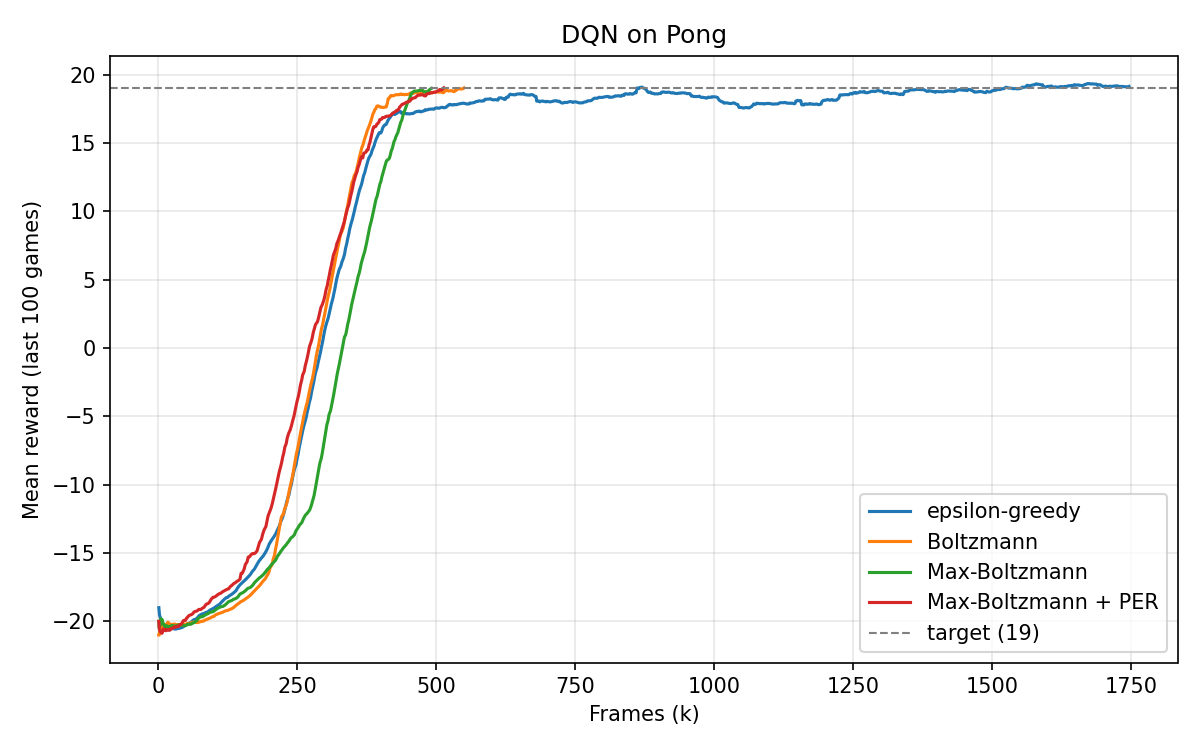

results/buffer_50k


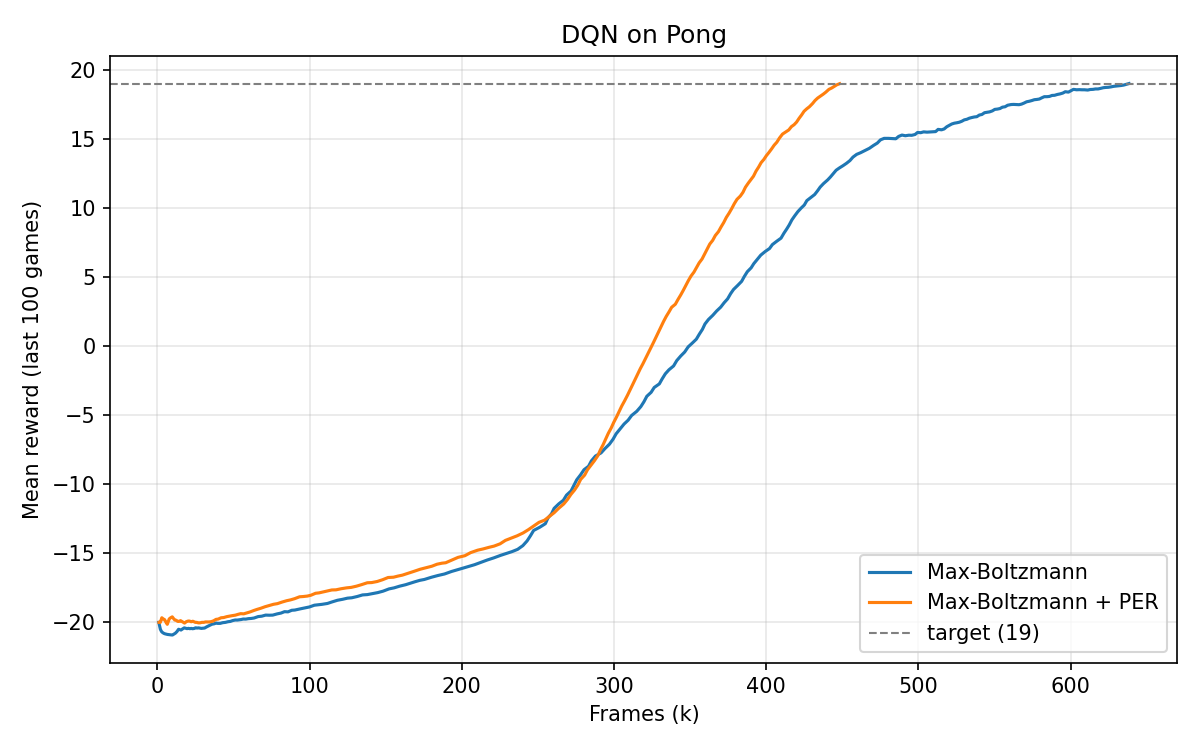

In [17]:
for d in ["results/buffer_10k", "results/buffer_50k"]:
    print(d)
    display(Image(f"{d}/compare_frames.png", width=760))

The same milestones recomputed straight from whichever TensorBoard event files are in `runs/`
(the 50k runs ship with this folder; the 10k runs appear once section 1 copies them in):

In [18]:
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator
import numpy as np

def label(d):
    name = os.path.basename(d.rstrip("/"))
    m = "Max-Boltzmann" if "maxboltz" in name else "Boltzmann" if "boltzmann" in name else "ε-greedy"
    return m + (" + PER" if name.endswith("-per") else "")

rows = []
for d in sorted(glob.glob("runs/buffer_*/*/")):
    ea = EventAccumulator(d, size_guidance={"scalars": 0}); ea.Reload()
    if "reward_100" not in ea.Tags()["scalars"]:
        continue
    ev = ea.Scalars("reward_100"); t0 = ea.FirstEventTimestamp()
    vals = np.array([e.value for e in ev])
    row = {"Run": label(d), "Buffer": d.split("/")[1].replace("buffer_", "")}
    for tgt in (0, 15, 19):
        hit = np.nonzero(vals >= tgt)[0]
        row[f"Frames to {tgt} (k)"] = round(ev[hit[0]].step / 1000) if len(hit) else None
        row[f"Minutes to {tgt}"] = round((ev[hit[0]].wall_time - t0) / 60, 1) if len(hit) else None
    rows.append(row)
display(Markdown(pd.DataFrame(rows).to_markdown(index=False)) if rows else Markdown("No event files found in runs/."))

| Run                 | Buffer   |   Frames to 0 (k) |   Minutes to 0 |   Frames to 15 (k) |   Minutes to 15 |   Frames to 19 (k) |   Minutes to 19 |
|:--------------------|:---------|------------------:|---------------:|-------------------:|----------------:|-------------------:|----------------:|
| Max-Boltzmann       | 50k      |               351 |           72.2 |                477 |            97.9 |                638 |           129.6 |
| Max-Boltzmann + PER | 50k      |               326 |           65.9 |                409 |            83.4 |                448 |            91.7 |

## 7. Comparison tables: baseline vs every technique

All numbers are to a mean reward of **19 over the last 100 games**, one run per configuration, on a Colab T4.
They load from the saved `results/` tables produced by `compare.py`.

In [19]:
def read_md_table(path):
    rows = [l.strip().strip("|").split("|") for l in open(path) if l.startswith("|")]
    return pd.DataFrame([[c.strip() for c in r] for r in rows[2:]], columns=[c.strip() for c in rows[0]])

runs = pd.concat([read_md_table("results/buffer_10k/results_table.md").assign(Buffer="10k"),
                  read_md_table("results/buffer_50k/results_table.md").assign(Buffer="50k")], ignore_index=True)
for c in ["Minutes to 19", "Frames to 19 (k)", "Best mean-100 reward"]:
    runs[c] = runs[c].astype(float)
runs["Method"] = runs["Method"].replace({"epsilon-greedy": "ε-greedy (baseline)"})
base = runs.iloc[0]
runs["Fewer frames vs baseline"] = (1 - runs["Frames to 19 (k)"] / base["Frames to 19 (k)"]).map("{:.0%}".format)
runs["Less time vs baseline"] = [f"{1 - m / base['Minutes to 19']:.0%}" if b == "10k" else "see note"
                                 for m, b in zip(runs["Minutes to 19"], runs["Buffer"])]
runs.loc[0, ["Fewer frames vs baseline", "Less time vs baseline"]] = "baseline"

master = runs[["Method", "Buffer", "Minutes to 19", "Frames to 19 (k)", "Best mean-100 reward",
               "Fewer frames vs baseline", "Less time vs baseline"]]
display(Markdown("**Table 1. Every run vs the baseline**\n\n" + master.to_markdown(index=False)))
display(Markdown("*Note:* the 50k runs ran at about 80 frames/s versus about 105 at 10k, because the repo's buffer is slower "
                 "to sample when large. Frames compare fairly across buffer sizes; minutes only within the same buffer size."))

**Table 1. Every run vs the baseline**

| Method              | Buffer   |   Minutes to 19 |   Frames to 19 (k) |   Best mean-100 reward | Fewer frames vs baseline   | Less time vs baseline   |
|:--------------------|:---------|----------------:|-------------------:|-----------------------:|:---------------------------|:------------------------|
| ε-greedy (baseline) | 10k      |           138.8 |                862 |                  19.36 | baseline                   | baseline                |
| Boltzmann           | 10k      |            86.5 |                550 |                  19.04 | 36%                        | 38%                     |
| Max-Boltzmann       | 10k      |            75.8 |                492 |                  19.01 | 43%                        | 45%                     |
| Max-Boltzmann + PER | 10k      |           101.4 |                514 |                  19.05 | 40%                        | 27%                     |
| Max-Boltzmann       | 50k      |           129.6 |                638 |                  19.04 | 26%                        | see note                |
| Max-Boltzmann + PER | 50k      |            91.7 |                448 |                  19.03 | 48%                        | see note                |

*Note:* the 50k runs ran at about 80 frames/s versus about 105 at 10k, because the repo's buffer is slower to sample when large. Frames compare fairly across buffer sizes; minutes only within the same buffer size.

In [20]:
step2 = master[(master["Buffer"] == "10k") & (~master["Method"].str.contains("PER"))]
display(Markdown("**Table 2. Step 2: exploration methods vs the baseline (goal: at least 10% better)**\n\n"
                 + step2.drop(columns="Buffer").to_markdown(index=False)))

**Table 2. Step 2: exploration methods vs the baseline (goal: at least 10% better)**

| Method              |   Minutes to 19 |   Frames to 19 (k) |   Best mean-100 reward | Fewer frames vs baseline   | Less time vs baseline   |
|:--------------------|----------------:|-------------------:|-----------------------:|:---------------------------|:------------------------|
| ε-greedy (baseline) |           138.8 |                862 |                  19.36 | baseline                   | baseline                |
| Boltzmann           |            86.5 |                550 |                  19.04 | 36%                        | 38%                     |
| Max-Boltzmann       |            75.8 |                492 |                  19.01 | 43%                        | 45%                     |

In [21]:
per_rows = []
for b in ["10k", "50k"]:
    plain = runs[(runs["Buffer"] == b) & (runs["Method"] == "Max-Boltzmann")].iloc[0]
    per = runs[(runs["Buffer"] == b) & (runs["Method"] == "Max-Boltzmann + PER")].iloc[0]
    df_ = 1 - per["Frames to 19 (k)"] / plain["Frames to 19 (k)"]
    dt_ = 1 - per["Minutes to 19"] / plain["Minutes to 19"]
    per_rows.append({"Buffer": b,
                     "Max-Boltzmann": f"{plain['Frames to 19 (k)']:.0f}k frames · {plain['Minutes to 19']} min",
                     "+ PER": f"{per['Frames to 19 (k)']:.0f}k frames · {per['Minutes to 19']} min",
                     "PER effect (frames)": f"{df_:.0%} fewer" if df_ > 0 else f"{-df_:.0%} more",
                     "PER effect (time)": f"{dt_:.0%} less" if dt_ > 0 else f"{-dt_:.0%} more"})
display(Markdown("**Table 3. Step 3: PER vs no PER at the same buffer size**\n\n"
                 + pd.DataFrame(per_rows).to_markdown(index=False)))

**Table 3. Step 3: PER vs no PER at the same buffer size**

| Buffer   | Max-Boltzmann           | + PER                   | PER effect (frames)   | PER effect (time)   |
|:---------|:------------------------|:------------------------|:----------------------|:--------------------|
| 10k      | 492k frames · 75.8 min  | 514k frames · 101.4 min | 4% more               | 34% more            |
| 50k      | 638k frames · 129.6 min | 448k frames · 91.7 min  | 30% fewer             | 29% less            |

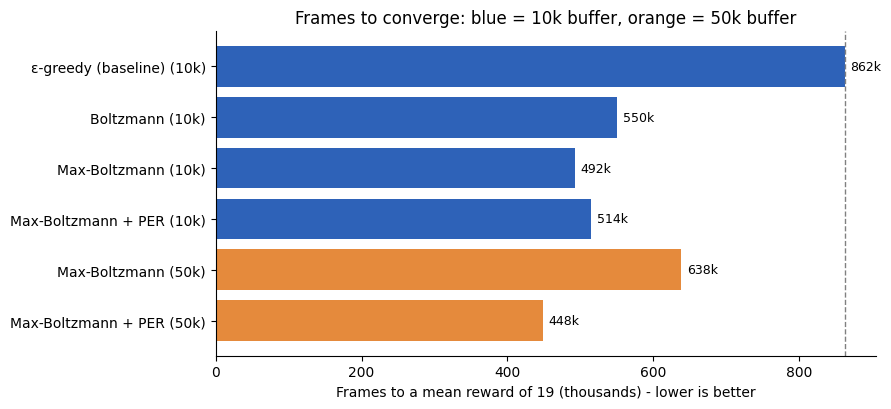

In [22]:
import matplotlib.pyplot as plt
plot = runs.assign(Label=runs["Method"] + " (" + runs["Buffer"] + ")").iloc[::-1]
colors = ["#2E62B8" if b == "10k" else "#E58A3C" for b in plot["Buffer"]]
fig, ax = plt.subplots(figsize=(9, 4.2))
bars = ax.barh(plot["Label"], plot["Frames to 19 (k)"], color=colors)
ax.axvline(base["Frames to 19 (k)"], ls="--", color="gray", lw=1)
for b, v in zip(bars, plot["Frames to 19 (k)"]):
    ax.text(v + 8, b.get_y() + b.get_height() / 2, f"{v:.0f}k", va="center", fontsize=9)
ax.set_xlabel("Frames to a mean reward of 19 (thousands) - lower is better")
ax.set_title("Frames to converge: blue = 10k buffer, orange = 50k buffer")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

## 8. Why the techniques work

To see *where* each method gains, we measured frames to three milestones: a mean reward of 0, 15 and 19.

In [23]:
ms = pd.read_csv("results/milestones.csv")
ms["Run"] = ms["run"] + " (" + ms["buffer_k"].astype(str) + "k)"
order = list(dict.fromkeys(ms["Run"]))
piv = ms.pivot(index="Run", columns="target", values="frames_k").loc[order]
piv.columns = [f"Frames to {c} (k)" for c in piv.columns]
base_ms = piv.loc["Baseline (ε-greedy) (10k)"]
explo = piv.loc[["Boltzmann (10k)", "Max-Boltzmann (10k)"]]
gain = (1 - explo / base_ms).apply(lambda col: col.map(lambda v: f"{v:.0%} fewer" if v >= 0 else f"{-v:.0%} more"))
gain.columns = [c.replace("Frames to", "vs baseline at").replace(" (k)", "") for c in gain.columns]
display(Markdown("**Table 4. Frames to each milestone**\n\n" + piv.reset_index().to_markdown(index=False)))
display(Markdown("**Table 5. Exploration methods vs the baseline at each milestone**\n\n" + gain.reset_index().to_markdown(index=False)))

**Table 4. Frames to each milestone**

| Run                       |   Frames to 0 (k) |   Frames to 15 (k) |   Frames to 19 (k) |
|:--------------------------|------------------:|-------------------:|-------------------:|
| Baseline (ε-greedy) (10k) |               293 |                390 |                862 |
| Boltzmann (10k)           |               288 |                371 |                550 |
| Max-Boltzmann (10k)       |               331 |                424 |                492 |
| Max-Boltzmann + PER (10k) |               272 |                381 |                514 |
| Max-Boltzmann (50k)       |               351 |                477 |                638 |
| Max-Boltzmann + PER (50k) |               326 |                409 |                448 |

**Table 5. Exploration methods vs the baseline at each milestone**

| Run                 | vs baseline at 0   | vs baseline at 15   | vs baseline at 19   |
|:--------------------|:-------------------|:--------------------|:--------------------|
| Boltzmann (10k)     | 2% fewer           | 5% fewer            | 36% fewer           |
| Max-Boltzmann (10k) | 13% more           | 9% more             | 43% fewer           |

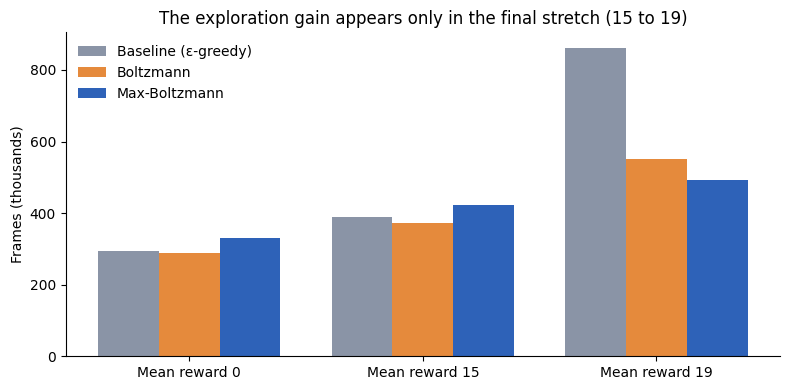

In [24]:
fig, ax = plt.subplots(figsize=(8, 4))
runs10 = ["Baseline (ε-greedy) (10k)", "Boltzmann (10k)", "Max-Boltzmann (10k)"]
x = np.arange(3); w = 0.26
for i, (r, c) in enumerate(zip(runs10, ["#8A94A6", "#E58A3C", "#2E62B8"])):
    ax.bar(x + (i - 1) * w, piv.loc[r].values, w, label=r.replace(" (10k)", ""), color=c)
ax.set_xticks(x, ["Mean reward 0", "Mean reward 15", "Mean reward 19"])
ax.set_ylabel("Frames (thousands)")
ax.set_title("The exploration gain appears only in the final stretch (15 to 19)")
ax.legend(frameon=False); ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

**Why smarter exploration works.** Up to a reward of 15, all three methods learn at a similar pace (Table 5).
The gap opens between 15 and 19: the baseline keeps taking 2% uniformly random moves, and near-perfect play is exactly where one random move loses a point.
Boltzmann and Max-Boltzmann still explore, but their exploratory moves are near-best, so they stop losing those points.
Pong also has duplicate actions (NOOP/FIRE, RIGHT/RIGHTFIRE, LEFT/LEFTFIRE), so softmax often spreads probability over equivalent moves at no cost.

**Why PER needs a bigger buffer.** With 10k transitions, uniform sampling already replays the informative steps often, and the repo's PER rescans every priority each step (about 20% fewer frames/s), so it gave no gain.
With 50k transitions, uniform sampling is diluted by stale, easy steps: plain Max-Boltzmann slowed to 638k frames, while PER, which keeps picking high-error steps, reached 19 in 448k (30% fewer frames, 29% less time).

## 9. Our contributions

| What we did | Evidence |
|---|---|
| Ported the 2018 textbook DQN to Gymnasium 1.x without changing the algorithm | `CHANGES_vs_repo.diff`; baseline reached 19 and won a test game 21–0 |
| Replaced ε-greedy with Boltzmann exploration | 36% fewer frames, 38% less time to 19 (Table 2) |
| Replaced ε-greedy with Max-Boltzmann exploration | 43% fewer frames, 45% less time to 19 (Table 2) |
| Added PER and found it needs a larger buffer | No gain at 10k; 30% fewer frames and 29% less time at 50k (Table 3) |
| Measured with TensorBoard in both frames and minutes, at three milestones | Section 6 and Tables 4–5 show where each gain comes from |

**Limits:** one run per configuration, so some of the smaller differences may be run-to-run variation; the large gains are well beyond the 10% target.

## 10. Test games
Each saved model plays one greedy game (21 is a perfect score). The 10k models appear here once section 1 copies them in.

In [25]:
for m in sorted(glob.glob("models/*.dat")):
    print("==", os.path.basename(m))
    !python 03_dqn_play.py -m "{m}" --no-visualize 2>&1 | grep "Total reward"

== PongNoFrameskip-v4-maxboltz-best.dat


Total reward: 21.00


== PongNoFrameskip-v4-maxboltz-per-best.dat


Total reward: 21.00


## 11. Save everything to a zip
Packs the code, results tables, plots, TensorBoard logs, console logs, models and notebooks into one timestamped zip.
In Colab it is also copied to Drive (`exports/`) and downloaded.

In [ ]:
import datetime
stamp = datetime.datetime.now().strftime("%Y%m%d_%H%M")
name = f"CMPE260_Project1_results_{stamp}"
stage = os.path.join("/tmp", name)
shutil.rmtree(stage, ignore_errors=True); os.makedirs(stage)
for item in ["results", "runs", "logs", "models", "notebooks", "lib"]:
    if os.path.exists(item):
        shutil.copytree(item, os.path.join(stage, item), ignore=shutil.ignore_patterns("__pycache__", ".ipynb_checkpoints"))
for f in glob.glob("*.py") + glob.glob("*.md") + glob.glob("*.txt") + glob.glob("*.diff"):
    shutil.copy2(f, stage)
archive = shutil.make_archive(stage, "zip", "/tmp", name)
print(f"Created {archive} ({os.path.getsize(archive) / 1e6:.1f} MB)")
if IN_COLAB:
    os.makedirs("exports", exist_ok=True)
    shutil.copy2(archive, "exports/")
    print("Copied to", os.path.join(PROJ, "exports"))
    from google.colab import files
    files.download(archive)

## References
- Lapan, M. (2018). *Deep Reinforcement Learning Hands-On*. Packt. Code: github.com/PacktPublishing/Deep-Reinforcement-Learning-Hands-On (Ch. 6 baseline, Ch. 7 PER).
- Mnih, V. et al. (2015). Human-level control through deep reinforcement learning. *Nature* 518, 529–533.
- Sutton, R. S. & Barto, A. G. (2018). *Reinforcement Learning: An Introduction* (2nd ed.). MIT Press.
- Wiering, M. A. (1999). *Explorations in Efficient Reinforcement Learning*. PhD thesis, University of Amsterdam.
- Schaul, T., Quan, J., Antonoglou, I. & Silver, D. (2016). Prioritized Experience Replay. ICLR.
- Towers, M. et al. (2024). Gymnasium: A Standard Interface for Reinforcement Learning Environments. arXiv:2407.17032.